### Initializare librarii pentru model

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import pickle

### Functie pentru incarcarea datelor si pentru realizarea matricei de confuzie

In [4]:
import pandas as pd

def loadData(file):
    df = pd.read_csv(file)
    data = {}
    for label in df['label'].unique():
        data[label] = df[df['label'] == label]['file_path'].tolist()
    return data

def plotConfusionMatrix(cm, classNames, title):
    import itertools

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

file_path = 'data/train.csv'
trainInputs= loadData(file_path)
file_path = 'data/val.csv'
validationInputs= loadData(file_path)
file_path = 'data/test.csv'
testInputs= loadData(file_path)

### Normalizarea datelor si antrenarea modelului


C:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2256 - loss: 1.3955 - val_accuracy: 0.2500 - val_loss: 1.3806
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2948 - loss: 1.3634 - val_accuracy: 0.5312 - val_loss: 1.2120
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5374 - loss: 1.0968 - val_accuracy: 0.5938 - val_loss: 0.8756
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.5340 - loss: 0.8849 - val_accuracy: 0.6375 - val_loss: 0.8330
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6258 - loss: 0.8043 - val_accuracy: 0.5938 - val_loss: 0.8005
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6084 - loss: 0.7758 - val_accuracy: 0.7188 - val_loss: 0.7233
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6383 - loss: 0.7484 - val_accuracy: 0.7563 - val_loss: 0.6775
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6860 - loss: 0.6667 - val_accuracy: 0.7125 - v

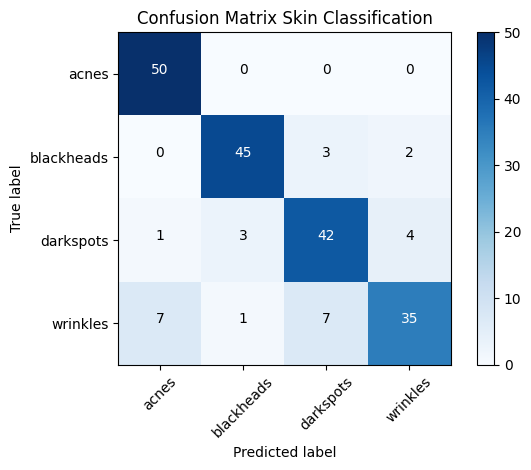

In [3]:
def prepareData(data_dict):
    inputs = []
    outputs = []
    for label, paths in data_dict.items():
        for path in paths:
            inputs.append(np.load(path))
            outputs.append(label)  
    inputs = np.array(inputs) / 255.0  
    outputs = np.array(outputs)  
    return inputs, outputs


# Prepare the datasets
trainInputs, trainOutputs = prepareData(trainInputs)
validationInputs, validationOutputs = prepareData(validationInputs)
testInputs, testOutputs = prepareData(testInputs)

label_encoder = LabelEncoder()
trainOutputs = label_encoder.fit_transform(trainOutputs)
validationOutputs = label_encoder.transform(validationOutputs)
testOutputs = label_encoder.transform(testOutputs)

trainOutputs = to_categorical(trainOutputs, num_classes=4)
validationOutputs = to_categorical(validationOutputs, num_classes=4)
testOutputs = to_categorical(testOutputs, num_classes=4)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=trainInputs.shape[1:]),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')  # 4 clase
])


# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    trainInputs, trainOutputs,
    epochs=100,
    batch_size=32,
    validation_data=(validationInputs, validationOutputs)
)

# Evaluate the model
test_loss, test_acc = model.evaluate(testInputs, testOutputs, verbose=2)
print('Test accuracy:', test_acc)

# Predict and round the results
pred_probs = model.predict(testInputs)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(testOutputs, axis=1)
cm = confusion_matrix(true_labels, pred_labels)
plotConfusionMatrix(cm, label_encoder.classes_, "Skin Classification")